# Explore here

### Planteamiento del Problema 

El objetivo es predecir si un cliente contratará un depósito a plazo.

- `y = yes`: contrata.
- `y = no`: no contrata.

In [17]:
# Your code here
# Carga de librerias
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme()

### Paso 1 carga de datos y storage en archivo csv

In [26]:
df = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")
df.shape
#df.head()
df.to_csv("../data/raw/bank-marketing-campaing-data.csv", index=False)

### Paso 2 Exploracion de Datos

In [32]:
#df.describe
df.info()
duplicados = df.duplicated().sum()
if duplicados > 0: 
    print(f'Total de duplicados removidos {duplicados}')
    df.drop_duplicates()
else: 
    print(f'Total de duplicados {duplicados}')

df.shape



<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

(41188, 21)

In [33]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


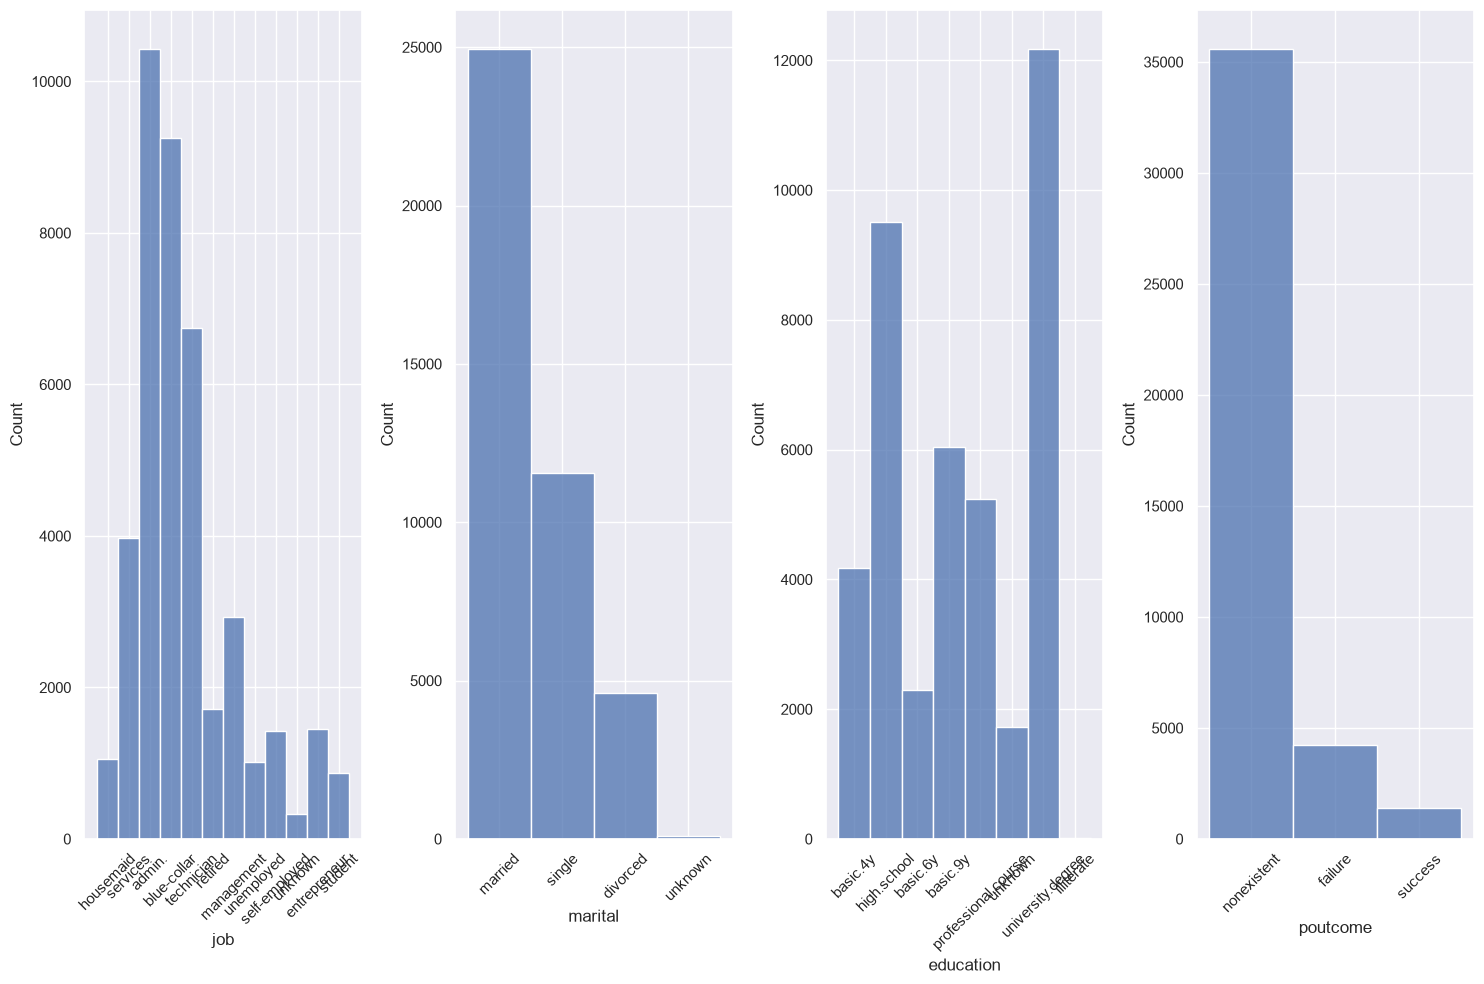

In [48]:
fig, axis = plt.subplots(1,4, figsize=(15,10)) 
columnas = ['job', 'marital', 'education', 'poutcome']
col=0
fila=1
for columna in columnas:
    sns.histplot(ax=axis[col], data=df, x=columna)
    axis[col].tick_params(axis='x', rotation=45)
    col+=1

plt.tight_layout()
plt.show()

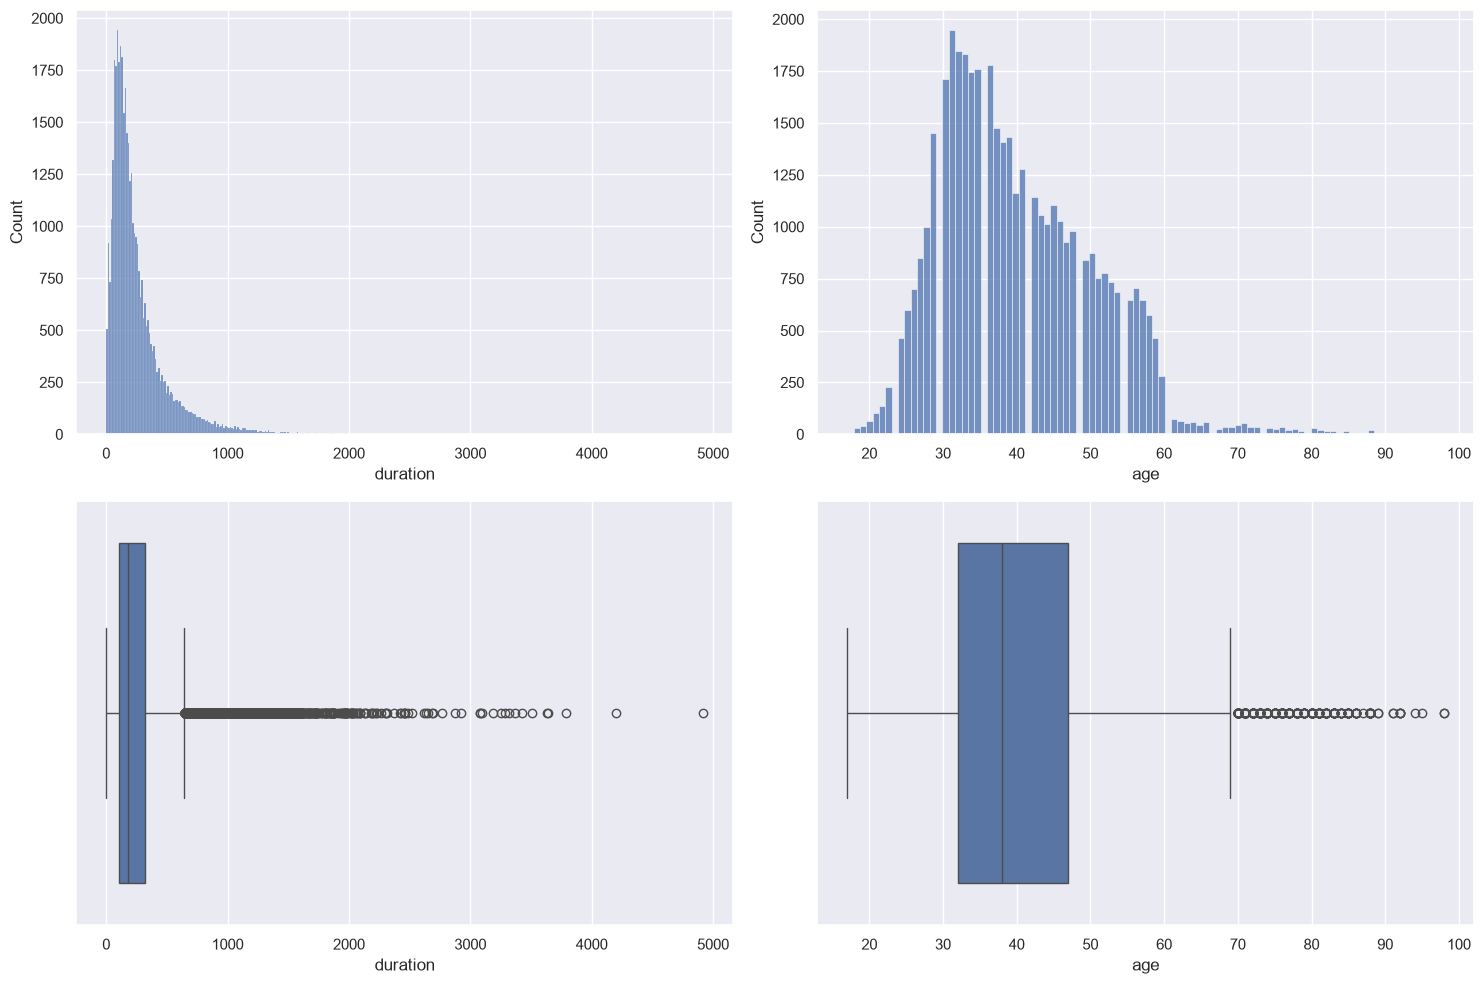

In [ ]:
fig, axis = plt.subplots(2, 3, figsize=(15, 10))

columnas = ['duration', 'age']

for col, columna in enumerate(columnas):

    # Histograma arriba
    sns.histplot(
        ax=axis[0, col],
        data=df,
        x=columna
    )

    # Boxplot abajo
    sns.boxplot(
        ax=axis[1, col],
        data=df,
        x=columna
    )

plt.tight_layout()
plt.show()

### Analisis Univariante

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [56]:
columnas = ['job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day_of_week',
    'poutcome',
    'y']

for columna in columnas:
    print(f'\n{columna}')
    print(df[columna].value_counts().head(5))
    #print(df[columna].value_counts(normalize=True).head(5) * 100)


job
job
admin.         10422
blue-collar     9254
technician      6743
services        3969
management      2924
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

month
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
Name: count, dtype: int64

day_of_week
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: c